In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import supervised_loss, consistency_loss, add_sup_losses

from debugger import bug_check


In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    in_chans=3,
    embed_dim=256,
    depth=4,
    num_heads=4,
    num_bins=128,
    dropout=0.1,
).to(device)

In [5]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debugg=False,
    return_two_pairs=True
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)

In [6]:
# bug_check(0)

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Hyperparameters
LAMBDA_CONS = 1.0
LAMBDA_OCC = 10.0
LAMBDA_RADIUS = 10.0
OCC_THRESH= 0.8

model.train()
for epoch in range(300):
    total = 0.0
    total_vis1 = 0.0
    total_radius1 = 0.0
    total_depth1 = 0.0
    total_pose1 = 0.0
    total_t1 = 0.0
    total_r1 = 0.0

    total_vis2 = 0.0
    total_radius2 = 0.0
    total_depth2 = 0.0
    total_pose2 = 0.0
    total_t2 = 0.0
    total_r2 = 0.0

    total_cons_loss = 0.0
    total_cons_occ = 0.0
    total_cons_rad = 0.0
    total_cons_dep = 0.0

    for batch in loader:
        # img_a1, vision_a1, img_b1, pose_ab1 = batch
        img_a1, vision_a1, img_b1, pose_ab1, img_a2, vision_a2, img_b2, pose_ab2 = batch

        img_a1 = img_a1.to(device, non_blocking=True)
        img_b1 = img_b1.to(device, non_blocking=True)
        vision_a1 = vision_a1.to(device, non_blocking=True)
        pose_ab1 = pose_ab1.to(device, non_blocking=True)
        img_a2 = img_a2.to(device, non_blocking=True)
        img_b2 = img_b2.to(device, non_blocking=True)
        vision_a2 = vision_a2.to(device, non_blocking=True)
        pose_ab2 = pose_ab2.to(device, non_blocking=True)

        pred_vision1, pred_pose1 = model(img_a1, img_b1)
        pred_vision2, pred_pose2 = model(img_a2, img_b2)

        loss_out1 = supervised_loss(pred_vision1, vision_a1, pred_pose1, pose_ab1,
                                    occ_thresh=OCC_THRESH,
                                    lambda_occ=LAMBDA_OCC,
                                    lambda_radius=LAMBDA_RADIUS,
        )

        loss_out2 = supervised_loss(pred_vision2, vision_a2, pred_pose2, pose_ab2,
                                    occ_thresh=OCC_THRESH,
                                    lambda_occ=LAMBDA_OCC,
                                    lambda_radius=LAMBDA_RADIUS,
        )

        cons_loss, cons_occ, cons_rad, cons_dep = consistency_loss(
            pred_vision1,
            pred_vision2,
            occ_thresh=0.5,
            match_thresh=0.25,
        )

        loss = loss_out1["total"] + loss_out2["total"] + LAMBDA_CONS * cons_loss

        #print(cons_loss)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total += loss.item()

        total_vis1, total_radius1, total_pose1, total_depth1, total_t1, total_r1 = add_sup_losses(
            total_vis1, total_radius1, total_pose1, total_depth1, total_t1, total_r1, loss_out1
        )
        total_vis2, total_radius2, total_pose2, total_depth2, total_t2, total_r2 = add_sup_losses(
            total_vis2, total_radius2, total_pose2, total_depth2, total_t2, total_r2, loss_out2
        )

        total_cons_loss += cons_loss.item()
        total_cons_occ += cons_occ.item()
        total_cons_rad += cons_rad.item()
        total_cons_dep += cons_dep.item()

    n = len(loader)

    print(
        f"Epoch {epoch+1}: "
        f"tot={total/n:.4f} | "
        f"vis={total_vis1/n:.4f} | "
        f"r={total_radius1/n:.4f} | "
        f"d={total_depth1/n:.4f} | "
        f"pose={total_pose1/n:.4f} | "
        f"t={total_t1/n:.4f} | "
        f"r={total_r1/n:.4f} | "
        f"cons={total_cons_loss/n:.4f} | "
        f"occ={total_cons_occ/n:.4f} | "
        f"cons_r={total_cons_rad/n:.4f} | "
        f"cons_d={total_cons_dep/n:.4f}"
    )

Epoch 1: tot=38.5384 | vis=18.6136 | r=0.2052 | d=9.6133 | pose=0.5561 | t=0.2534 | r=0.3027 | cons=0.0238 | occ=0.0015 | cons_r=0.0110 | cons_d=0.0113
Epoch 2: tot=36.6331 | vis=17.8545 | r=0.1893 | d=9.2605 | pose=0.3470 | t=0.2499 | r=0.0971 | cons=0.0209 | occ=0.0008 | cons_r=0.0098 | cons_d=0.0103
Epoch 3: tot=36.2514 | vis=17.6467 | r=0.1817 | d=9.3675 | pose=0.3070 | t=0.2525 | r=0.0545 | cons=0.0210 | occ=0.0006 | cons_r=0.0102 | cons_d=0.0102
Epoch 4: tot=36.6904 | vis=18.3366 | r=0.1680 | d=10.3844 | pose=0.3014 | t=0.2464 | r=0.0550 | cons=0.0220 | occ=0.0005 | cons_r=0.0106 | cons_d=0.0109
Epoch 5: tot=36.5872 | vis=17.0494 | r=0.1554 | d=9.3896 | pose=0.3043 | t=0.2506 | r=0.0537 | cons=0.0248 | occ=0.0004 | cons_r=0.0115 | cons_d=0.0128
Epoch 6: tot=37.5078 | vis=17.6608 | r=0.1611 | d=10.1417 | pose=0.3096 | t=0.2471 | r=0.0625 | cons=0.0252 | occ=0.0008 | cons_r=0.0116 | cons_d=0.0127
Epoch 7: tot=34.8738 | vis=17.0735 | r=0.1623 | d=9.7150 | pose=0.3046 | t=0.2471 | r=

In [11]:
# Inference + utskrift + plottar på samma dataset som träningen
from utils import pose_to_text, show_image_pair

infer_dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    return_two_pairs=False
)

infer_loader = DataLoader(
    infer_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)
model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_pose = model(img_a, img_b)

# Skriv ut resultat för några samples
n_show = min(4, img_a.shape[0])
for i in range(n_show):
    print(f"Sample {i}")
    print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
    print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

    pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
    print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
    print()

Sample 0
  GT   pose: tx=0.763, ty=0.647, yaw=30.8°
  Pred pose: tx=0.969, ty=0.613, yaw=23.0°
  |err|     : tx=0.207, ty=0.034, sin=0.122, cos=0.062

Sample 1
  GT   pose: tx=-0.045, ty=0.999, yaw=-16.9°
  Pred pose: tx=-0.086, ty=1.069, yaw=-18.6°
  |err|     : tx=0.041, ty=0.070, sin=0.028, cos=0.009

Sample 2
  GT   pose: tx=0.729, ty=0.685, yaw=-10.8°
  Pred pose: tx=0.552, ty=0.831, yaw=-9.0°
  |err|     : tx=0.177, ty=0.146, sin=0.030, cos=0.005

Sample 3
  GT   pose: tx=0.454, ty=-0.891, yaw=5.5°
  Pred pose: tx=0.212, ty=-0.671, yaw=-0.2°
  |err|     : tx=0.242, ty=0.221, sin=0.098, cos=0.005



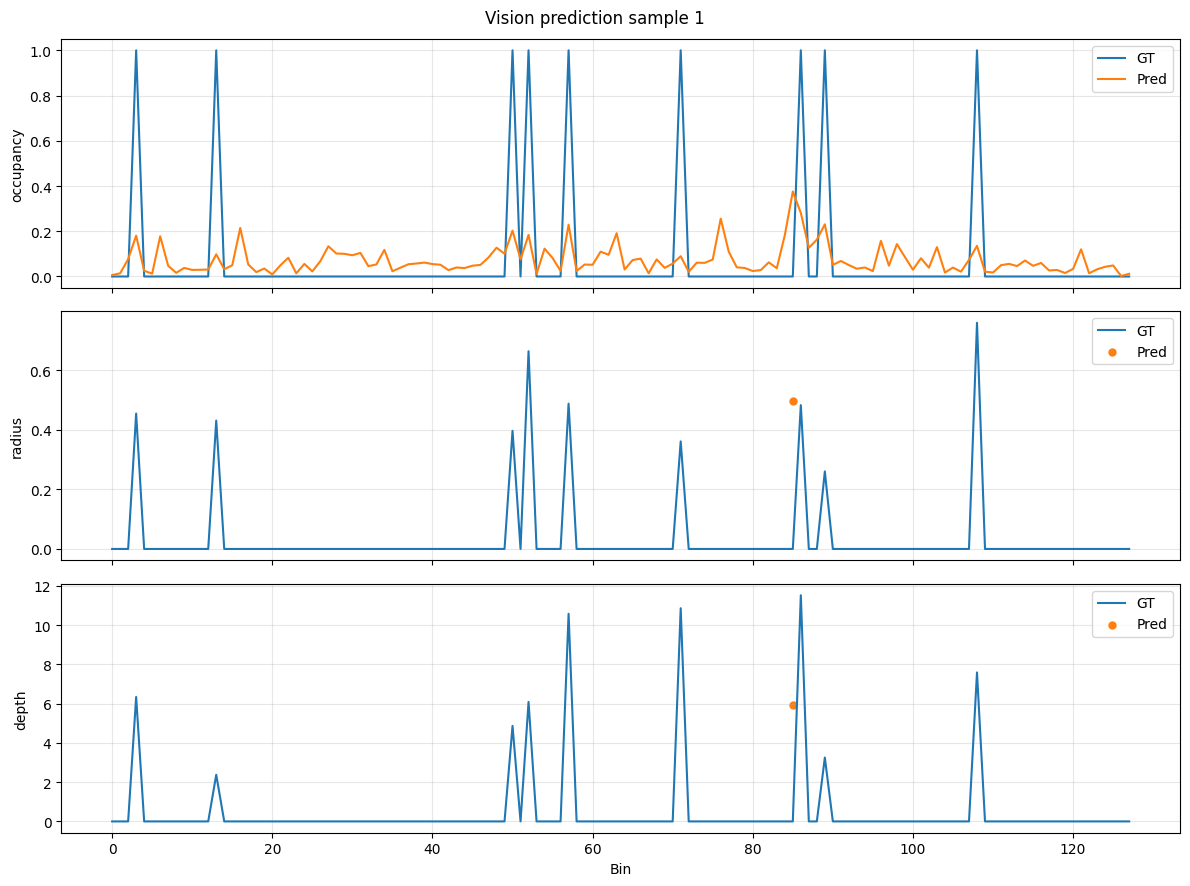

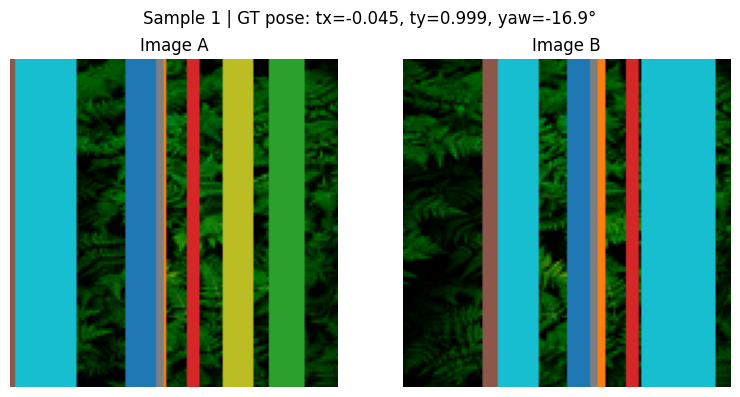

In [16]:
# Plotta vision-output för första samplet
sample_idx = 1
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
occ_threshold = 0.3

gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    # GT alltid blå linje
    ax.plot(bins, gt, label="GT", color="tab:blue")

    if j == 0:
        # occupancy: pred som orange linje
        ax.plot(bins, pr, label="Pred", color="tab:orange")
    else:
        pr_mask = pr_occ > occ_threshold

        # pred som orange punkter
        ax.scatter(
            bins[pr_mask],
            pr[pr_mask],
            label="Pred",
            color="tab:orange",
            s=25
        )

    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()

# Plotta bildpar
show_image_pair(
    img_a[sample_idx].detach().cpu(),
    img_b[sample_idx].detach().cpu(),
    title=f"Sample {sample_idx} | GT pose: {pose_to_text(pose_ab[sample_idx].detach().cpu())}"
)

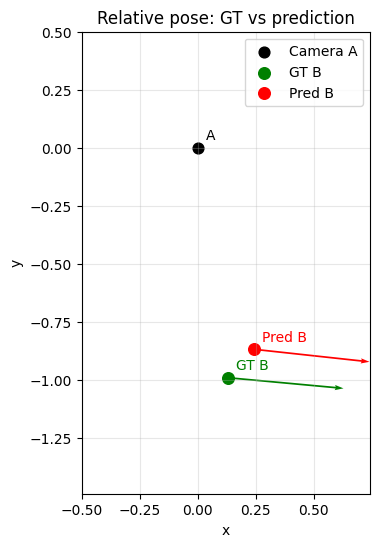

pred_vision shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([ 0.1308, -0.9914, -0.0916,  0.9958])
Pred pose: tensor([ 0.2436, -0.8690, -0.1078,  0.9942])


In [10]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from utils import plot_relative_pose


# Visa första paret i batchen
if False:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())